In [1]:
!! pip install pandas

['Defaulting to user installation because normal site-packages is not writeable',
 'Requirement already satisfied: pandas in c:\\anaconda\\lib\\site-packages (2.3.3)',
 'Requirement already satisfied: numpy>=1.26.0 in c:\\anaconda\\lib\\site-packages (from pandas) (2.3.5)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in c:\\anaconda\\lib\\site-packages (from pandas) (2.9.0.post0)',
 'Requirement already satisfied: pytz>=2020.1 in c:\\anaconda\\lib\\site-packages (from pandas) (2025.2)',
 'Requirement already satisfied: tzdata>=2022.7 in c:\\anaconda\\lib\\site-packages (from pandas) (2025.2)',
 'Requirement already satisfied: six>=1.5 in c:\\anaconda\\lib\\site-packages (from python-dateutil>=2.8.2->pandas) (1.17.0)']

In [2]:
!! pip install numpy
!! pip install matplotlib

['Defaulting to user installation because normal site-packages is not writeable',
 'Requirement already satisfied: matplotlib in c:\\anaconda\\lib\\site-packages (3.10.6)',
 'Requirement already satisfied: contourpy>=1.0.1 in c:\\anaconda\\lib\\site-packages (from matplotlib) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in c:\\anaconda\\lib\\site-packages (from matplotlib) (0.11.0)',
 'Requirement already satisfied: fonttools>=4.22.0 in c:\\anaconda\\lib\\site-packages (from matplotlib) (4.60.1)',
 'Requirement already satisfied: kiwisolver>=1.3.1 in c:\\anaconda\\lib\\site-packages (from matplotlib) (1.4.9)',
 'Requirement already satisfied: numpy>=1.23 in c:\\anaconda\\lib\\site-packages (from matplotlib) (2.3.5)',
 'Requirement already satisfied: packaging>=20.0 in c:\\anaconda\\lib\\site-packages (from matplotlib) (25.0)',
 'Requirement already satisfied: pillow>=8 in c:\\anaconda\\lib\\site-packages (from matplotlib) (12.0.0)',
 'Requirement already satisfied: pyparsing

In [6]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt

dataset = pd.read_csv(r"C:\Users\henrique_dahmer\Downloads\Nova pasta\Nova pasta\dados_automacao_weg_bruto.csv")
display(dataset)

,ID_EQUIP_CONFUSO,TEMP_VAL_RAW,PRES_PSI_RAW,STATUS_TXT,OP_GENERO_ERR,CONS_KWH_VAL
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790
...,...,...,...,...,...,...
2145,WEG-AUT-1004,90.843566,4.061965,Ativo,M,117.655855
2146,WEG-AUT-1003,58.390508,4.722875,Ocioso,M,130.301611
2147,WEG-AUT-1002,66.500781,6.376775,Ativo,F,110.372679
2148,WEG-AUT-1001,74.115825,4.821483,Ativo,M,111.459729


In [8]:
print("\n --- Tamanho do Dataset Bruto ---")
print(dataset.shape)
#2150 linhas para 6 colunas


 --- Tamanho do Dataset Bruto ---
(2150, 6)


In [9]:
print("Primeiras linhas do Dataset bruto")
print(dataset.head())

Primeiras linhas do Dataset bruto
  ID_EQUIP_CONFUSO  TEMP_VAL_RAW  PRES_PSI_RAW  STATUS_TXT OP_GENERO_ERR  \
0     WEG-AUT-1000     80.415499      5.953804       Ativo             M   
1     WEG-AUT-1001     73.748225      8.526058       Ativo             F   
2     WEG-AUT-1002     82.000730      6.229241  Manutenção             M   
3     WEG-AUT-1003     91.191813      6.522981       Ativo             F   
4     WEG-AUT-1004     72.741390      4.435769       Ativo             M   

   CONS_KWH_VAL  
0    143.638137  
1    119.283011  
2    109.098388  
3    106.835740  
4    124.990790  


In [10]:
#Corrigir os cabeçalhos do sistema para os padrões técnicos da WEG
dataset.columns = ['id', 'temperatura', 'pressao', 'status', 'genero', 'consumo_kwh']

#validar a alteração
dataset.head()

,id,temperatura,pressao,status,genero,consumo_kwh
0,WEG-AUT-1000,80.415499,5.953804,Ativo,M,143.638137
1,WEG-AUT-1001,73.748225,8.526058,Ativo,F,119.283011
2,WEG-AUT-1002,82.000730,6.229241,Manutenção,M,109.098388
3,WEG-AUT-1003,91.191813,6.522981,Ativo,F,106.835740
4,WEG-AUT-1004,72.741390,4.435769,Ativo,M,124.990790


In [11]:
#Agrupar e explorar a coluna de Status
grupado_status = dataset.groupby(['status']).size()
print(grupado_status)

status
Ativo         1527
Manutenção     403
Ocioso         220
dtype: int64


In [12]:
#Agrupar e explorar a coluna de Gênero
grupado_genero = dataset.groupby(['genero']).size()
print(grupado_genero)

genero
F     799
M    1351
dtype: int64


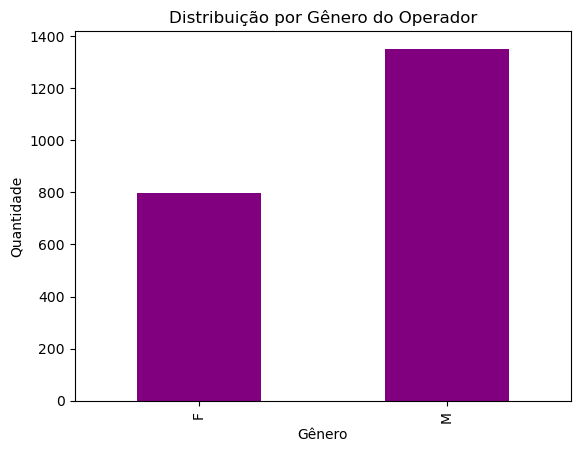

In [20]:
#Gerar o gráfico de barras na cor cinza para a variável gênero
grupado_genero.plot.bar(color = 'purple')
plt.title('Distribuição por Gênero do Operador')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

In [22]:
print("Resumo estatístico para verificar desvios e anomalias")
dataset.describe()

Resumo estatístico para verificar desvios e anomalias


,temperatura,pressao,consumo_kwh
count,2105.000000,2100.000000,2150.000000
mean,146.289206,6.466018,120.237563
std,834.958013,3.941850,14.895532
min,41.166693,1.989315,61.163996
25%,68.714655,5.225650,110.544661
50%,75.657826,6.200258,120.296560
75%,82.518021,7.150509,130.093832
max,9999.000000,55.000000,170.660744
